# Análise Brasil

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df_participantes = pd.read_csv(
                    "data/2025/PARTICIPANTES_2025.csv",
                    sep=";",
                    encoding="latin1"
)

## Realizando amostragem 

In [3]:
n_amostra = 100_000

proporcao_uf = (
    df_participantes['SG_UF_PROVA']
    .value_counts(normalize=True)
)

n_por_uf = (
    proporcao_uf * n_amostra
).round().astype(int)

In [4]:
amostras = []

for uf, n in n_por_uf.items():

    df_uf = df_participantes[
        df_participantes['SG_UF_PROVA'] == uf
    ]

    amostra_uf = df_uf.sample(
        n=min(n, len(df_uf)),
        random_state=42
    )

    amostras.append(amostra_uf)

df_nacional_amostra = pd.concat(amostras)

In [5]:
df_nacional_amostra.shape

(99999, 38)

In [7]:
LIMIAR_BAIXA_RENDA = 1518.0 / 2
LIMIAR_BAIXA_RENDA

759.0

In [8]:
faixas_renda = {
    "A": (0, 0),
    "B": (0, 1412),
    "C": (1412.01, 2118),
    "D": (2118.01, 2824),
    "E": (2824.01, 3530),
    "F": (3530.01, 4236),
    "G": (4236.01, 4942),
    "H": (4942.01, 7060),
    "I": (7060.01, 8472),
    "J": (8472.01, 9884),
    "K": (9884.01, 11296),
    "L": (11296.01, 12708),
    "M": (12708.01, 14120),
    "N": (14120.01, 16944),
    "O": (16944.01, 21180),
    "P": (21180.01, 28240),
    "Q": (28240.01, np.inf)
}

In [9]:
renda_media = {}

for faixa, (limite_inferior, limite_superior) in faixas_renda.items():
    if np.isfinite(limite_superior):
        renda_media[faixa] = (limite_inferior + limite_superior) / 2
    else:
        renda_media[faixa] = np.nan

In [10]:
df_nacional_amostra["RENDA_FAMILIAR_EST"] = (df_nacional_amostra["Q007"].map(renda_media))
df_nacional_amostra.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST
2605433,210069179140,2025,4,F,1,3,1,1,1,NaN,0,3522505,Itapevi,35,SP,A,A,B,B,10,A,A,A,B,A,A,A,B,A,A,A,A,A,A,A,A,B,A,0.000
2428831,210069001677,2025,1,M,1,1,1,3,0,NaN,1,3549805,São José do Rio Preto,35,SP,G,G,E,E,3,A,P,B,D,C,C,A,B,A,B,B,B,B,B,B,D,D,D,24710.005
1427813,210067969679,2025,1,M,1,1,2,3,0,NaN,1,3516408,Franco da Rocha,35,SP,E,G,D,E,3,A,M,A,B,C,B,B,B,A,B,B,B,B,B,B,D,E,D,13414.005
1622265,210068168807,2025,2,M,1,3,1,2,0,1.0,0,3530607,Mogi das Cruzes,35,SP,E,E,B,B,4,A,C,A,C,C,B,A,B,A,A,B,A,B,A,B,A,B,A,1765.005
4695540,210071322268,2025,2,F,1,1,1,2,0,1.0,0,3516705,Garça,35,SP,E,F,C,A,4,A,D,A,B,D,B,A,B,B,B,B,B,D,A,B,A,E,E,2471.005


In [11]:
df_nacional_amostra["RENDA_PER_CAP_EST"] = np.where(
    df_nacional_amostra["Q005"] > 0,
    df_nacional_amostra["RENDA_FAMILIAR_EST"] / df_nacional_amostra["Q005"],
    np.nan
)
df_nacional_amostra.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST
2605433,210069179140,2025,4,F,1,3,1,1,1,NaN,0,3522505,Itapevi,35,SP,A,A,B,B,10,A,A,A,B,A,A,A,B,A,A,A,A,A,A,A,A,B,A,0.000,0.000000
2428831,210069001677,2025,1,M,1,1,1,3,0,NaN,1,3549805,São José do Rio Preto,35,SP,G,G,E,E,3,A,P,B,D,C,C,A,B,A,B,B,B,B,B,B,D,D,D,24710.005,8236.668333
1427813,210067969679,2025,1,M,1,1,2,3,0,NaN,1,3516408,Franco da Rocha,35,SP,E,G,D,E,3,A,M,A,B,C,B,B,B,A,B,B,B,B,B,B,D,E,D,13414.005,4471.335000
1622265,210068168807,2025,2,M,1,3,1,2,0,1.0,0,3530607,Mogi das Cruzes,35,SP,E,E,B,B,4,A,C,A,C,C,B,A,B,A,A,B,A,B,A,B,A,B,A,1765.005,441.251250
4695540,210071322268,2025,2,F,1,1,1,2,0,1.0,0,3516705,Garça,35,SP,E,F,C,A,4,A,D,A,B,D,B,A,B,B,B,B,B,D,A,B,A,E,E,2471.005,617.751250


In [12]:
df_nacional_amostra["BAIXA_RENDA_EST"] = np.select(
    [
        df_nacional_amostra["RENDA_PER_CAP_EST"].isna(),
        df_nacional_amostra["RENDA_PER_CAP_EST"] <= 706
    ],
    [
        None,
        "Sim"
    ],
    default="Nao"
)

df_nacional_amostra.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
2605433,210069179140,2025,4,F,1,3,1,1,1,NaN,0,3522505,Itapevi,35,SP,A,A,B,B,10,A,A,A,B,A,A,A,B,A,A,A,A,A,A,A,A,B,A,0.000,0.000000,Sim
2428831,210069001677,2025,1,M,1,1,1,3,0,NaN,1,3549805,São José do Rio Preto,35,SP,G,G,E,E,3,A,P,B,D,C,C,A,B,A,B,B,B,B,B,B,D,D,D,24710.005,8236.668333,Nao
1427813,210067969679,2025,1,M,1,1,2,3,0,NaN,1,3516408,Franco da Rocha,35,SP,E,G,D,E,3,A,M,A,B,C,B,B,B,A,B,B,B,B,B,B,D,E,D,13414.005,4471.335000,Nao
1622265,210068168807,2025,2,M,1,3,1,2,0,1.0,0,3530607,Mogi das Cruzes,35,SP,E,E,B,B,4,A,C,A,C,C,B,A,B,A,A,B,A,B,A,B,A,B,A,1765.005,441.251250,Sim
4695540,210071322268,2025,2,F,1,1,1,2,0,1.0,0,3516705,Garça,35,SP,E,F,C,A,4,A,D,A,B,D,B,A,B,B,B,B,B,D,A,B,A,E,E,2471.005,617.751250,Sim


In [13]:
df_nacional_amostra[df_nacional_amostra["BAIXA_RENDA_EST"] == None]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST


In [14]:
df_nacional_amostra[
    ["Q005", "Q007", "RENDA_FAMILIAR_EST", "RENDA_PER_CAP_EST", "BAIXA_RENDA_EST"]
].head()

,Q005,Q007,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
2605433,10,A,0.000,0.000000,Sim
2428831,3,P,24710.005,8236.668333,Nao
1427813,3,M,13414.005,4471.335000,Nao
1622265,4,C,1765.005,441.251250,Sim
4695540,4,D,2471.005,617.751250,Sim


In [15]:
df_nacional_amostra["BAIXA_RENDA_EST"].value_counts(dropna=False)

BAIXA_RENDA_EST
Sim    64724
Nao    34011
NaN     1264
Name: count, dtype: int64

In [16]:
df_nacional_amostra["Q007"].value_counts(dropna=False).sort_index()

Q007
A     9826
B    34197
C    18057
D     8983
E     4282
F     4856
G     5574
H     2812
I     2245
J     1790
K     1487
L      592
M     1075
N      931
O      997
P     1031
Q     1264
Name: count, dtype: int64

In [17]:
df_nacional_amostra[df_nacional_amostra["BAIXA_RENDA_EST"] == 'Nao']

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
2428831,210069001677,2025,1,M,1,1,1,3,0,NaN,1,3549805,São José do Rio Preto,35,SP,G,G,E,E,3,A,P,B,D,C,C,A,B,A,B,B,B,B,B,B,D,D,D,24710.005,8236.668333,Nao
1427813,210067969679,2025,1,M,1,1,2,3,0,NaN,1,3516408,Franco da Rocha,35,SP,E,G,D,E,3,A,M,A,B,C,B,B,B,A,B,B,B,B,B,B,D,E,D,13414.005,4471.335000,Nao
2028760,210068586458,2025,3,M,1,1,1,2,0,1.0,0,3550308,São Paulo,35,SP,E,F,D,D,5,A,J,A,D,D,B,A,C,A,B,B,B,D,A,B,D,E,D,9178.005,1835.601000,Nao
4187957,210070803341,2025,3,F,1,1,1,2,0,1.0,0,3538709,Piracicaba,35,SP,E,E,D,B,5,A,G,A,B,C,B,A,B,A,B,B,B,C,A,B,B,E,A,4589.005,917.801000,Nao
2931862,210069515223,2025,11,M,1,1,1,1,9,NaN,0,3551504,Serrana,35,SP,E,D,D,B,4,B,F,A,C,D,A,A,B,A,B,A,A,B,B,B,B,E,A,3883.005,970.751250,Nao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3892673,210070500200,2025,10,M,2,1,3,1,0,NaN,0,1400100,Boa Vista,14,RR,E,F,A,D,2,A,C,A,B,B,A,B,B,A,A,A,A,B,A,A,A,C,F,1765.005,882.502500,Nao
4387595,210071009056,2025,11,M,1,3,1,1,9,NaN,0,1400100,Boa Vista,14,RR,E,E,F,B,2,A,C,A,C,C,B,A,B,A,B,A,B,B,A,B,B,C,A,1765.005,882.502500,Nao
2940268,210069523641,2025,3,M,1,3,3,2,0,1.0,0,1400100,Boa Vista,14,RR,C,H,C,B,3,A,D,A,B,B,A,A,B,A,B,A,A,B,A,B,B,D,A,2471.005,823.668333,Nao
4520944,210071145900,2025,2,F,1,3,1,2,0,1.0,0,1400100,Boa Vista,14,RR,E,E,C,D,5,A,I,A,C,D,A,B,B,A,B,A,A,A,A,B,B,E,A,7766.005,1553.201000,Nao


## Distribuição dos Participantes por Renda Familiar

In [18]:
renda_familiar = (
    df_nacional_amostra['Q007']
    .value_counts()
    .sort_index()
)

renda_familiar

Q007
A     9826
B    34197
C    18057
D     8983
E     4282
F     4856
G     5574
H     2812
I     2245
J     1790
K     1487
L      592
M     1075
N      931
O      997
P     1031
Q     1264
Name: count, dtype: int64

In [19]:
percentuais_renda = (
    df_nacional_amostra['Q007']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

percentuais_renda

Q007
A     9.826098
B    34.197342
C    18.057181
D     8.983090
E     4.282043
F     4.856049
G     5.574056
H     2.812028
I     2.245022
J     1.790018
K     1.487015
L     0.592006
M     1.075011
N     0.931009
O     0.997010
P     1.031010
Q     1.264013
Name: proportion, dtype: float64

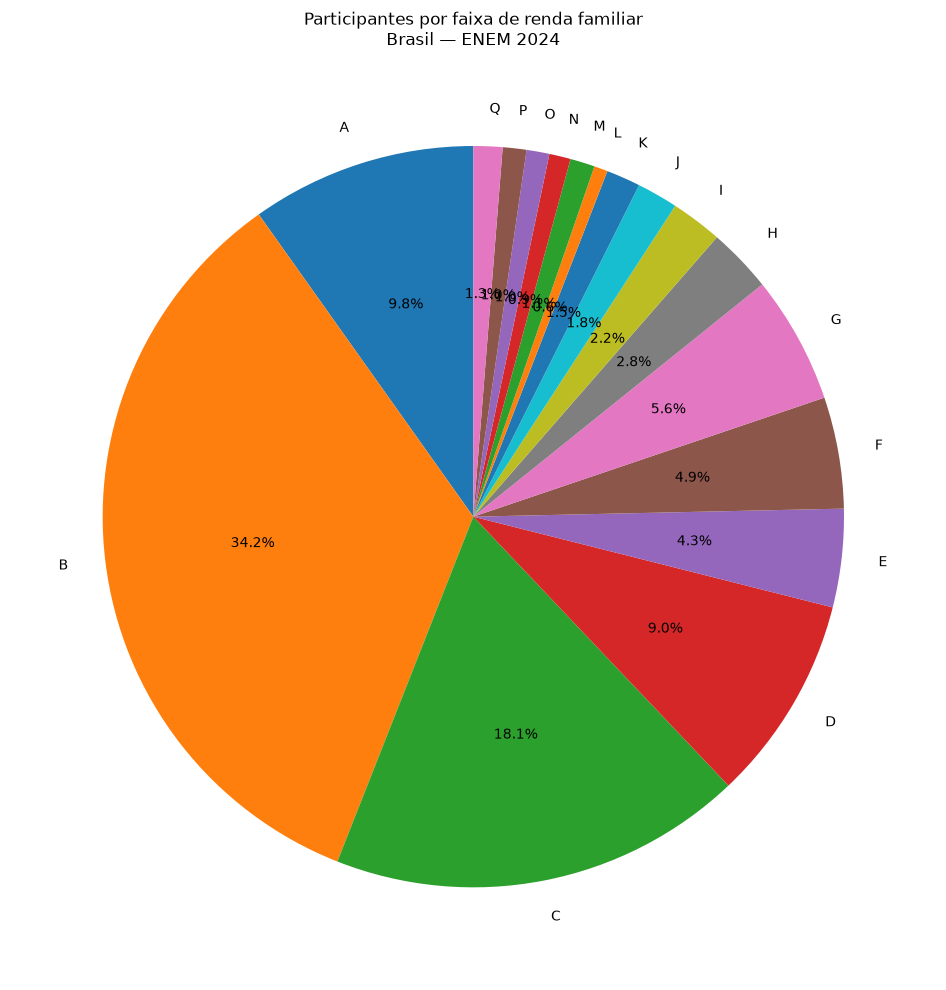

In [20]:
renda_familiar = (
    df_nacional_amostra['Q007']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 10))

plt.pie(
    renda_familiar,
    labels=renda_familiar.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Participantes por faixa de renda familiar\n'
    'Brasil — ENEM 2024'
)

plt.tight_layout()
plt.show()

In [21]:
# Agrupamento das categorias oficiais do Q007
grupos_renda = {
    'Sem renda': ['A'],
    'Até 1,5 SM': ['B', 'C'],
    'De 1,5 a 3 SM': ['D', 'E', 'F'],
    'De 3 a 6 SM': ['G', 'H', 'I'],
    'De 6 a 10 SM': ['J', 'K', 'L', 'M'],
    'Acima de 10 SM': ['N', 'O', 'P', 'Q']
}

# Cria um dicionário categoria Q007 -> grupo
mapa_renda = {
    categoria: grupo
    for grupo, categorias in grupos_renda.items()
    for categoria in categorias
}

# Cria a nova coluna
df_nacional_amostra['GRUPO_RENDA'] = df_nacional_amostra['Q007'].map(mapa_renda)

# Frequência dos grupos
distribuicao_renda = (
    df_nacional_amostra['GRUPO_RENDA']
    .value_counts()
    .reindex(grupos_renda.keys())
)

distribuicao_renda

GRUPO_RENDA
Sem renda          9826
Até 1,5 SM        52254
De 1,5 a 3 SM     18121
De 3 a 6 SM       10631
De 6 a 10 SM       4944
Acima de 10 SM     4223
Name: count, dtype: int64

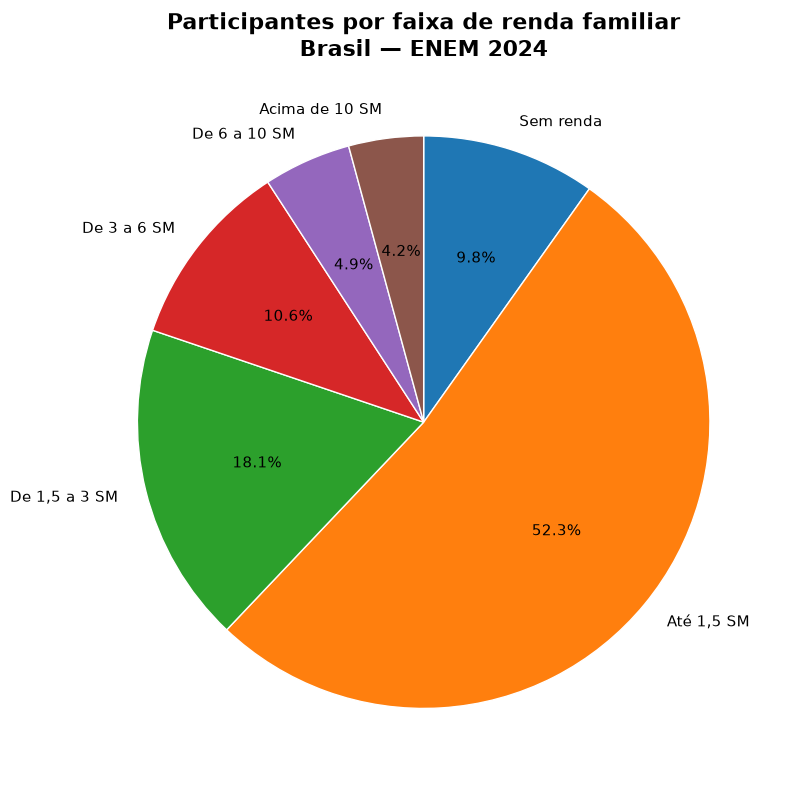

In [22]:
plt.figure(figsize=(10, 8))

plt.pie(
    distribuicao_renda,
    labels=distribuicao_renda.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 11},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

plt.title(
    'Participantes por faixa de renda familiar\n'
    'Brasil — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

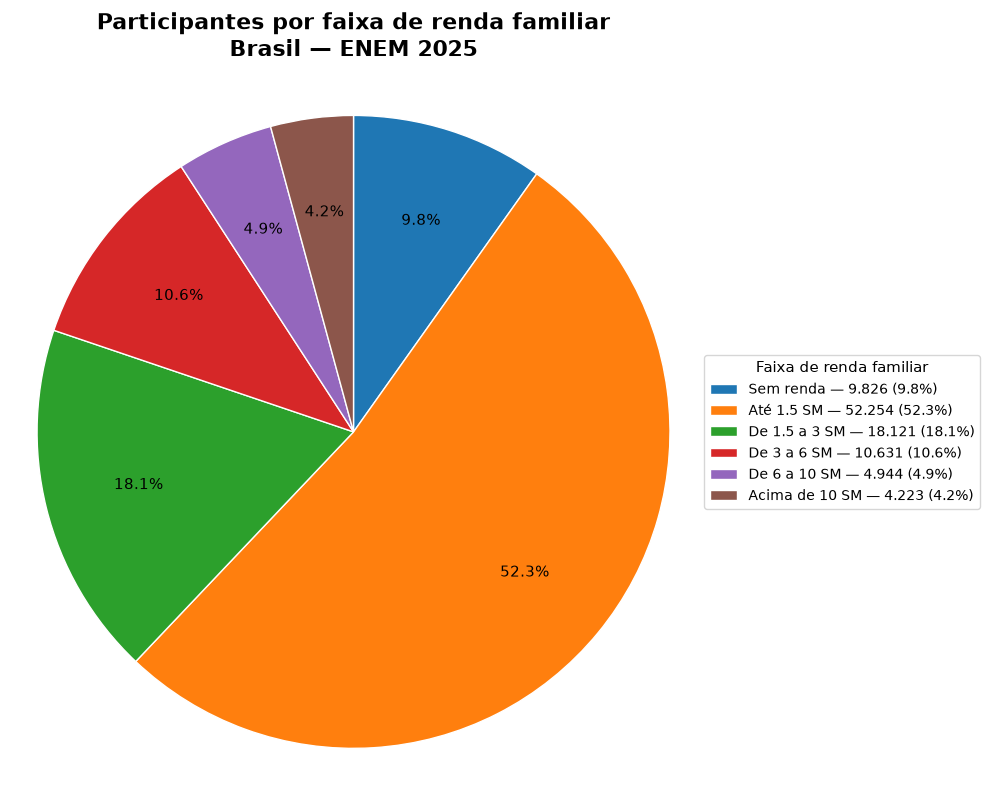

In [24]:
# Frequência dos grupos
distribuicao_renda = (
    df_nacional_amostra['GRUPO_RENDA']
    .value_counts()
    .reindex(grupos_renda.keys())
)

total = distribuicao_renda.sum()

# Percentuais
percentuais = distribuicao_renda / total * 100

# Texto da legenda
legenda = [
    f'{grupo} — {valor:,} ({percentual:.1f}%)'.replace(',', '.')
    for grupo, valor, percentual
    in zip(
        distribuicao_renda.index,
        distribuicao_renda.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(10, 8))

ax.pie(
    distribuicao_renda,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 11},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Faixa de renda familiar',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=11
)

ax.set_title(
    'Participantes por faixa de renda familiar\n'
    'Brasil — ENEM 2025',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

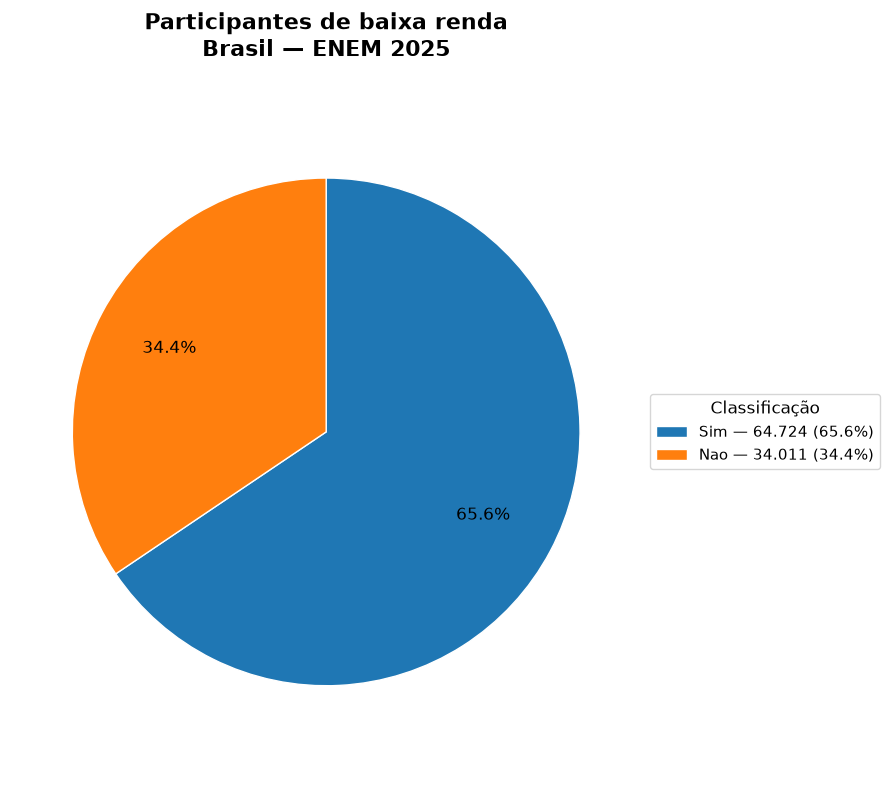

In [25]:
distribuicao_baixa_renda = (
    df_nacional_amostra['BAIXA_RENDA_EST']
    .dropna()
    .value_counts()
    .reindex(['Sim', 'Nao'], fill_value=0)
)

total = distribuicao_baixa_renda.sum()

percentuais = distribuicao_baixa_renda / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_baixa_renda.index,
        distribuicao_baixa_renda.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_baixa_renda,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Classificação',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Participantes de baixa renda\n'
    'Brasil — ENEM 2025',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

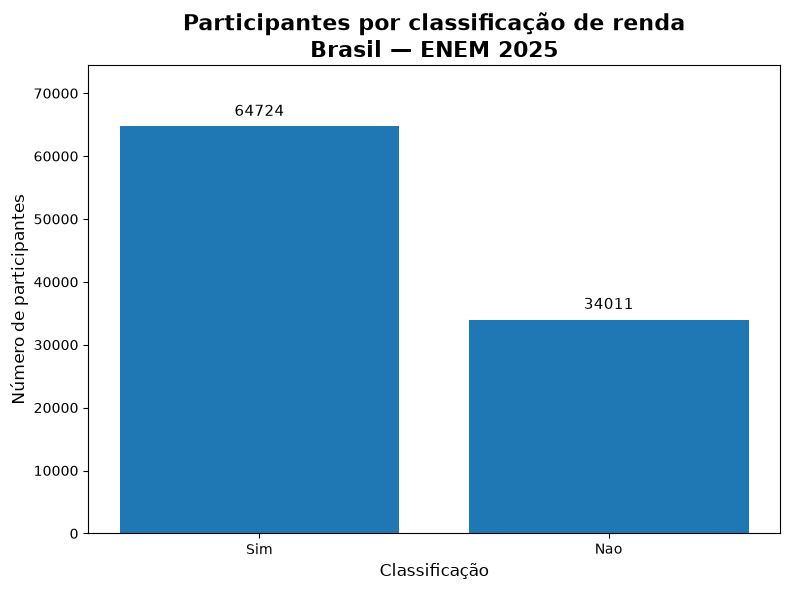

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(
    distribuicao_baixa_renda.index,
    distribuicao_baixa_renda.values
)

ax.set_title(
    'Participantes por classificação de renda\n'
    'Brasil — ENEM 2025',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Classificação', fontsize=12)
ax.set_ylabel('Número de participantes', fontsize=12)

# Mostra o valor sobre cada barra
ax.bar_label(
    barras,
    fmt='%d',
    padding=5,
    fontsize=11
)

ax.set_ylim(
    0,
    distribuicao_baixa_renda.max() * 1.15
)

plt.tight_layout()
plt.show()

## Distribuição dos Participantes por Sexo Biológico

In [27]:
df_nacional_amostra['TP_SEXO'].value_counts(dropna=False)

TP_SEXO
F    60086
M    39913
Name: count, dtype: int64

In [28]:
distribuicao_sexo = (
    df_nacional_amostra['TP_SEXO']
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)
distribuicao_sexo

TP_SEXO
F    60.09
M    39.91
Name: proportion, dtype: float64

In [29]:
nomes_sexo = {
    'M': 'Masculino',
    'F': 'Feminino'
}

distribuicao_sexo.index = distribuicao_sexo.index.map(nomes_sexo)

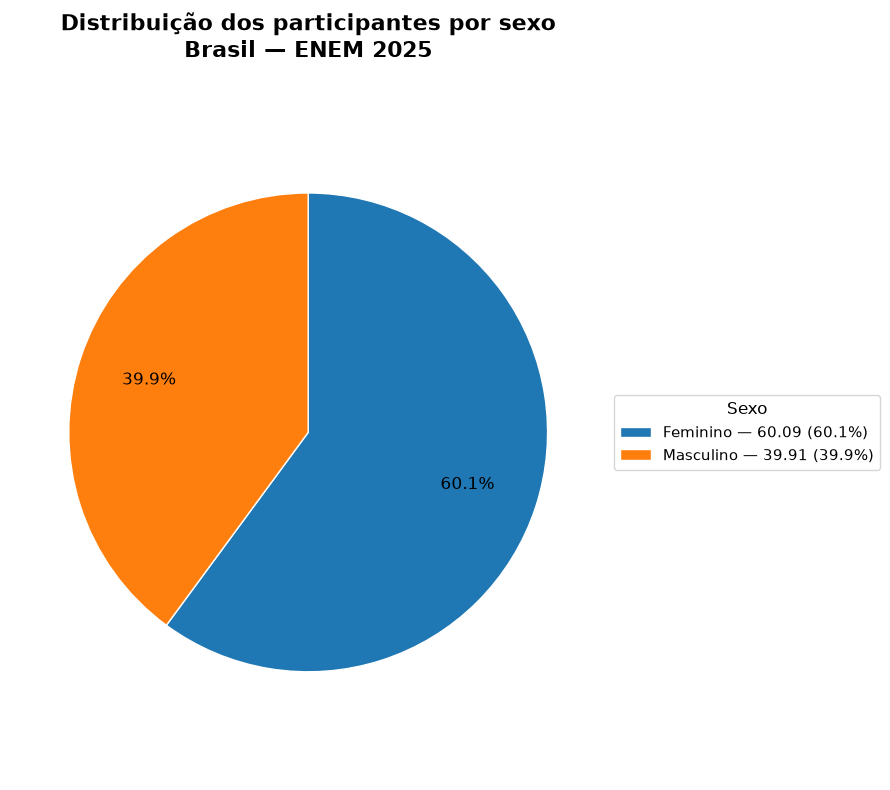

In [31]:

total = distribuicao_sexo.sum()

percentuais = distribuicao_sexo / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_sexo.index,
        distribuicao_sexo.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_sexo,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Sexo',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Distribuição dos participantes por sexo\n'
    'Brasil — ENEM 2025',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

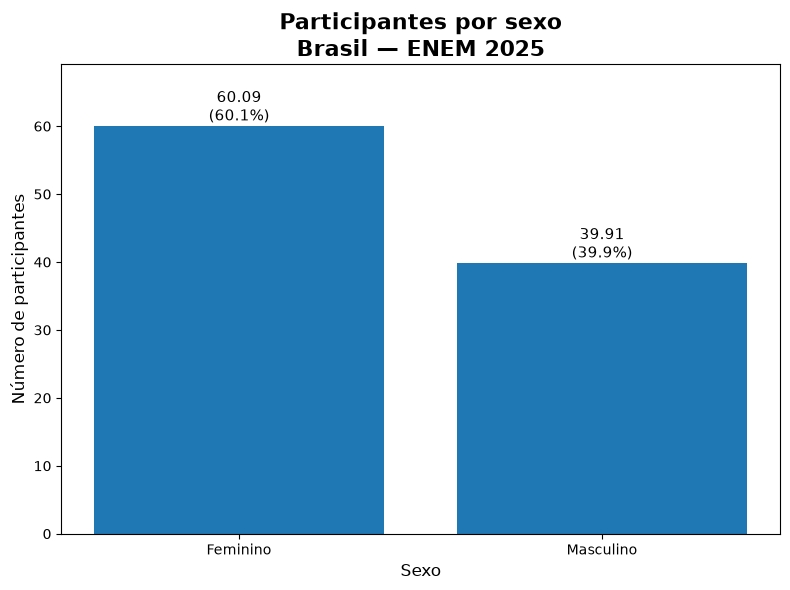

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(
    distribuicao_sexo.index,
    distribuicao_sexo.values
)

for barra, valor in zip(barras, distribuicao_sexo.values):
    percentual = valor / total * 100
    
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f'{valor:,}\n({percentual:.1f}%)'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.set_title(
    'Participantes por sexo\n'
    'Brasil — ENEM 2025',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Sexo', fontsize=12)
ax.set_ylabel('Número de participantes', fontsize=12)

ax.set_ylim(0, distribuicao_sexo.max() * 1.15)

plt.tight_layout()
plt.show()

## Participação dos Candidatos Negros e Pardos

In [33]:
df_nacional_amostra['TP_COR_RACA'].value_counts(dropna=False)

TP_COR_RACA
3    44552
1    39600
2    12472
4     1406
0     1148
5      821
Name: count, dtype: int64

In [34]:
cor_raca = (
    df_nacional_amostra['TP_COR_RACA']
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

cor_raca

TP_COR_RACA
3    44.55
1    39.60
2    12.47
4     1.41
0     1.15
5     0.82
Name: proportion, dtype: float64

In [35]:
mapa_cor_raca = {
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena'
}

df_nacional_amostra['COR_RACA'] = (
    df_nacional_amostra['TP_COR_RACA']
    .map(mapa_cor_raca)
)

In [36]:
df_nacional_amostra['TP_COR_RACA'].value_counts(normalize=True).mul(100).sort_index()

TP_COR_RACA
0     1.148011
1    39.600396
2    12.472125
3    44.552446
4     1.406014
5     0.821008
Name: proportion, dtype: float64

In [37]:
df_nacional_amostra['GRUPO_RACIAL'] = (
    df_nacional_amostra['TP_COR_RACA']
    .map({
        0: 'Não declarado',
        1: 'Branca',
        2: 'Preta',
        3: 'Parda',
        4: 'Amarela',
        5: 'Indígena',
        6: 'Não dispõe da informação'
    })
)

In [38]:
df_nacional_amostra['GRUPO_RACIAL'].value_counts()

GRUPO_RACIAL
Parda            44552
Branca           39600
Preta            12472
Amarela           1406
Não declarado     1148
Indígena           821
Name: count, dtype: int64

In [39]:
df_nacional_amostra['NEGRO'] = (
    df_nacional_amostra['TP_COR_RACA']
    .isin([2, 3])
    .map({
        True: 'Preta ou Parda',
        False: 'Demais categorias'
    })
)

In [40]:
distribuicao_negros = (
    df_nacional_amostra['NEGRO']
    .value_counts()
)

distribuicao_negros

NEGRO
Preta ou Parda       57024
Demais categorias    42975
Name: count, dtype: int64

In [41]:
percentuais_negros = (
    df_nacional_amostra['NEGRO']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

percentuais_negros

NEGRO
Preta ou Parda       57.02
Demais categorias    42.98
Name: proportion, dtype: float64

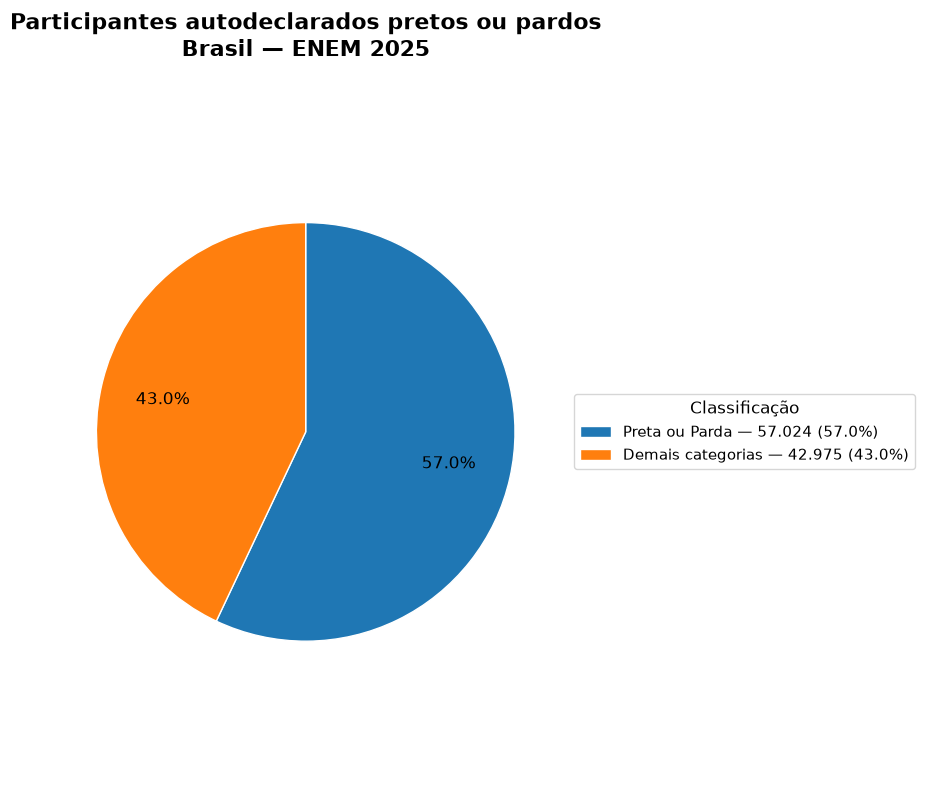

In [42]:
distribuicao_negros = (
    df_nacional_amostra['NEGRO']
    .value_counts()
    .reindex(['Preta ou Parda', 'Demais categorias'])
)

total = distribuicao_negros.sum()

percentuais = distribuicao_negros / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_negros.index,
        distribuicao_negros.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_negros,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Classificação',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Participantes autodeclarados pretos ou pardos\n'
    'Brasil — ENEM 2025',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

## Distribuição por Faixa Etária

In [43]:
df_nacional_amostra['TP_FAIXA_ETARIA'].describe()

count    99999.000000
mean         4.762028
std          3.915728
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         20.000000
Name: TP_FAIXA_ETARIA, dtype: float64

In [45]:
distribuicao_idade = (
    df_nacional_amostra['TP_FAIXA_ETARIA']
    .value_counts()
    .sort_index()
)

distribuicao_idade

TP_FAIXA_ETARIA
1     12132
2     21303
3     23814
4     10105
5      5578
6      3821
7      2858
8      2106
9      1797
10     1500
11     5243
12     3089
13     2321
14     1752
15     1178
16      689
17      383
18      199
19       94
20       37
Name: count, dtype: int64

In [46]:
percentuais_idade = (
    df_nacional_amostra['TP_FAIXA_ETARIA']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

percentuais_idade

TP_FAIXA_ETARIA
1     12.13
2     21.30
3     23.81
4     10.11
5      5.58
6      3.82
7      2.86
8      2.11
9      1.80
10     1.50
11     5.24
12     3.09
13     2.32
14     1.75
15     1.18
16     0.69
17     0.38
18     0.20
19     0.09
20     0.04
Name: proportion, dtype: float64

In [47]:
faixas_etarias = {
    1: 'Menor de 17 anos',
    2: '17 anos',
    3: '18 anos',
    4: '19 anos',
    5: '20 anos',
    6: '21 anos',
    7: '22 anos',
    8: '23 anos',
    9: '24 anos',
    10: '25 anos',
    11: '26–30 anos',
    12: '31–35 anos',
    13: '36–40 anos',
    14: '41–45 anos',
    15: '46–50 anos',
    16: '51–55 anos',
    17: '56–60 anos',
    18: '61–65 anos',
    19: '66–70 anos',
    20: 'Maior de 70 anos'
}

df_nacional_amostra['FAIXA_ETARIA'] = (
    df_nacional_amostra['TP_FAIXA_ETARIA']
    .map(faixas_etarias)
)

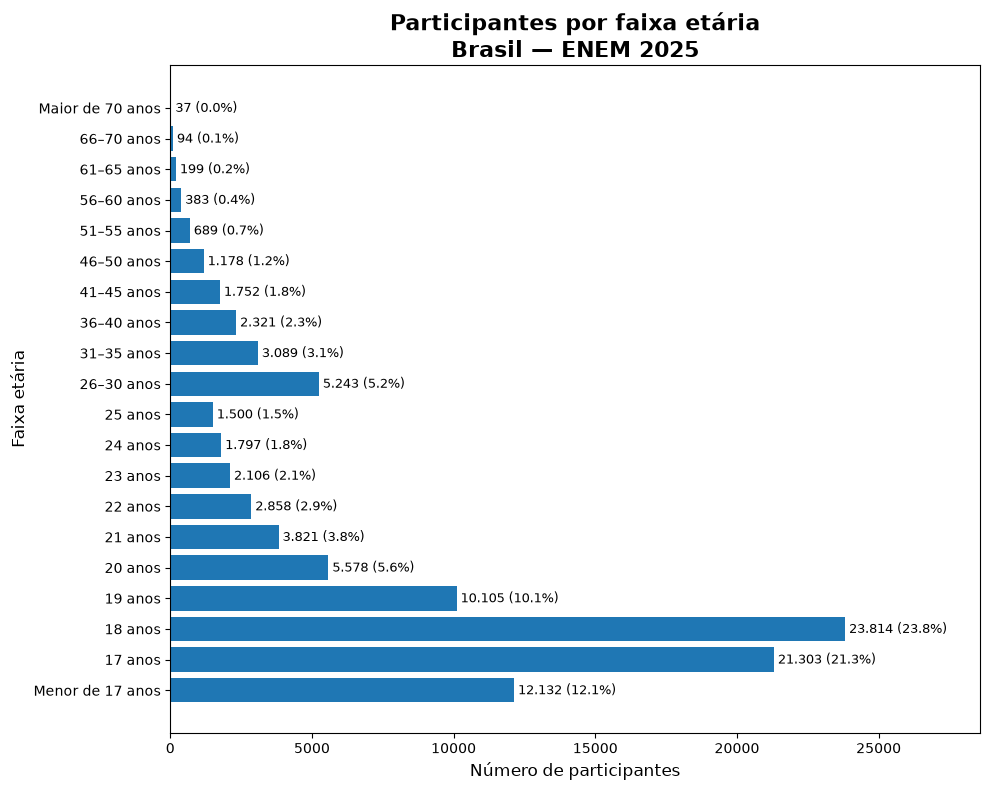

In [48]:
distribuicao_idade = (
    df_nacional_amostra['FAIXA_ETARIA']
    .value_counts()
)

ordem_faixas = list(faixas_etarias.values())

distribuicao_idade = (
    distribuicao_idade
    .reindex(ordem_faixas)
    .dropna()
)

total = distribuicao_idade.sum()

percentuais = (
    distribuicao_idade / total * 100
)

fig, ax = plt.subplots(figsize=(10, 8))

barras = ax.barh(
    distribuicao_idade.index,
    distribuicao_idade.values
)

for barra, valor, percentual in zip(
    barras,
    distribuicao_idade.values,
    percentuais.values
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f' {int(valor):,} ({percentual:.1f}%)'.replace(',', '.'),
        va='center',
        fontsize=9
    )

ax.set_title(
    'Participantes por faixa etária\n'
    'Brasil — ENEM 2025',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Número de participantes', fontsize=12)
ax.set_ylabel('Faixa etária', fontsize=12)

ax.set_xlim(
    0,
    distribuicao_idade.max() * 1.20
)

plt.tight_layout()
plt.show()

## Análise Santo Amaro

In [59]:
df_santo_amaro = df_participantes[
    (df_participantes['NO_MUNICIPIO_PROVA'] == 'Santo Amaro') & (df_participantes['SG_UF_PROVA'] == 'BA') ].copy();

In [60]:
faixas_renda = {
    "A": (0, 0),
    "B": (0, 1412),
    "C": (1412.01, 2118),
    "D": (2118.01, 2824),
    "E": (2824.01, 3530),
    "F": (3530.01, 4236),
    "G": (4236.01, 4942),
    "H": (4942.01, 7060),
    "I": (7060.01, 8472),
    "J": (8472.01, 9884),
    "K": (9884.01, 11296),
    "L": (11296.01, 12708),
    "M": (12708.01, 14120),
    "N": (14120.01, 16944),
    "O": (16944.01, 21180),
    "P": (21180.01, 28240),
    "Q": (28240.01, np.inf)
}

In [61]:
renda_media = {}

for faixa, (limite_inferior, limite_superior) in faixas_renda.items():
    if np.isfinite(limite_superior):
        renda_media[faixa] = (limite_inferior + limite_superior) / 2
    else:
        renda_media[faixa] = np.nan

In [62]:
df_santo_amaro["RENDA_FAMILIAR_EST"] = (df_santo_amaro["Q007"].map(renda_media))
df_santo_amaro.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST
642,210066507039,2025,3,M,1,3,1,1,1,NaN,0,2928604,Santo Amaro,29,BA,C,E,D,F,3,B,B,A,B,C,A,A,B,B,B,B,A,C,B,B,C,D,A,706.000
4311,210066512398,2025,3,F,1,2,1,2,0,1.0,0,2928604,Santo Amaro,29,BA,B,F,A,C,5,A,C,A,B,C,A,A,B,A,B,A,A,B,B,B,A,C,A,1765.005
11249,210066520216,2025,4,F,2,3,1,1,2,NaN,0,2928604,Santo Amaro,29,BA,H,E,B,B,2,A,B,A,B,C,A,A,B,A,B,A,A,B,A,B,A,B,A,706.000
13861,210066522973,2025,4,M,1,1,1,2,0,1.0,0,2928604,Santo Amaro,29,BA,C,B,B,B,2,A,A,A,B,B,A,A,B,A,A,A,A,B,A,B,A,B,A,0.000
16118,210066525232,2025,12,F,1,2,2,4,0,NaN,0,2928604,Santo Amaro,29,BA,B,B,C,B,3,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,0.000


In [63]:
df_santo_amaro["RENDA_PER_CAP_EST"] = np.where(
    df_santo_amaro["Q005"] > 0,
    df_santo_amaro["RENDA_FAMILIAR_EST"] / df_santo_amaro["Q005"],
    np.nan
)
df_santo_amaro.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST
642,210066507039,2025,3,M,1,3,1,1,1,NaN,0,2928604,Santo Amaro,29,BA,C,E,D,F,3,B,B,A,B,C,A,A,B,B,B,B,A,C,B,B,C,D,A,706.000,235.333333
4311,210066512398,2025,3,F,1,2,1,2,0,1.0,0,2928604,Santo Amaro,29,BA,B,F,A,C,5,A,C,A,B,C,A,A,B,A,B,A,A,B,B,B,A,C,A,1765.005,353.001000
11249,210066520216,2025,4,F,2,3,1,1,2,NaN,0,2928604,Santo Amaro,29,BA,H,E,B,B,2,A,B,A,B,C,A,A,B,A,B,A,A,B,A,B,A,B,A,706.000,353.000000
13861,210066522973,2025,4,M,1,1,1,2,0,1.0,0,2928604,Santo Amaro,29,BA,C,B,B,B,2,A,A,A,B,B,A,A,B,A,A,A,A,B,A,B,A,B,A,0.000,0.000000
16118,210066525232,2025,12,F,1,2,2,4,0,NaN,0,2928604,Santo Amaro,29,BA,B,B,C,B,3,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,0.000,0.000000


In [64]:
df_santo_amaro["BAIXA_RENDA_EST"] = np.select(
    [
        df_santo_amaro["RENDA_PER_CAP_EST"].isna(),
        df_santo_amaro["RENDA_PER_CAP_EST"] <= 706
    ],
    [
        None,
        "Sim"
    ],
    default="Nao"
)

df_santo_amaro.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
642,210066507039,2025,3,M,1,3,1,1,1,NaN,0,2928604,Santo Amaro,29,BA,C,E,D,F,3,B,B,A,B,C,A,A,B,B,B,B,A,C,B,B,C,D,A,706.000,235.333333,Sim
4311,210066512398,2025,3,F,1,2,1,2,0,1.0,0,2928604,Santo Amaro,29,BA,B,F,A,C,5,A,C,A,B,C,A,A,B,A,B,A,A,B,B,B,A,C,A,1765.005,353.001000,Sim
11249,210066520216,2025,4,F,2,3,1,1,2,NaN,0,2928604,Santo Amaro,29,BA,H,E,B,B,2,A,B,A,B,C,A,A,B,A,B,A,A,B,A,B,A,B,A,706.000,353.000000,Sim
13861,210066522973,2025,4,M,1,1,1,2,0,1.0,0,2928604,Santo Amaro,29,BA,C,B,B,B,2,A,A,A,B,B,A,A,B,A,A,A,A,B,A,B,A,B,A,0.000,0.000000,Sim
16118,210066525232,2025,12,F,1,2,2,4,0,NaN,0,2928604,Santo Amaro,29,BA,B,B,C,B,3,A,A,A,A,B,A,A,A,A,A,A,A,A,A,A,A,A,A,0.000,0.000000,Sim


In [65]:
df_santo_amaro[df_santo_amaro["BAIXA_RENDA_EST"] == None]

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST


In [66]:
df_santo_amaro[
    ["Q005", "Q007", "RENDA_FAMILIAR_EST", "RENDA_PER_CAP_EST", "BAIXA_RENDA_EST"]
].head()

,Q005,Q007,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
642,3,B,706.000,235.333333,Sim
4311,5,C,1765.005,353.001000,Sim
11249,2,B,706.000,353.000000,Sim
13861,2,A,0.000,0.000000,Sim
16118,3,A,0.000,0.000000,Sim


In [67]:
df_santo_amaro["BAIXA_RENDA_EST"].value_counts(dropna=False)

BAIXA_RENDA_EST
Sim    1881
Nao     227
NaN       1
Name: count, dtype: int64

In [68]:
df_santo_amaro["Q007"].value_counts(dropna=False).sort_index()

Q007
A     467
B    1130
C     282
D      91
E      38
F      39
G      25
H       8
I       8
J       4
K      10
L       2
O       3
P       1
Q       1
Name: count, dtype: int64

In [69]:
df_santo_amaro[df_santo_amaro["BAIXA_RENDA_EST"] == 'Nao']

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ENSINO,IN_TREINEIRO,CO_MUNICIPIO_PROVA,NO_MUNICIPIO_PROVA,CO_UF_PROVA,SG_UF_PROVA,Q001,Q002,Q003,Q004,Q005,Q006,Q007,Q008,Q009,Q010,Q011,Q012,Q013,Q014,Q015,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,RENDA_FAMILIAR_EST,RENDA_PER_CAP_EST,BAIXA_RENDA_EST
16165,210066525279,2025,2,F,1,2,1,2,0,1.0,0,2928604,Santo Amaro,29,BA,G,E,E,D,3,A,K,A,C,C,B,A,B,A,B,B,B,C,B,B,C,D,D,10590.005,3530.001667,Nao
40050,210066549183,2025,4,M,1,3,1,1,2,NaN,0,2928604,Santo Amaro,29,BA,G,G,E,F,3,A,O,A,D,D,B,A,C,A,B,B,B,D,A,B,C,D,D,19062.005,6354.001667,Nao
114220,210066623620,2025,4,M,1,1,1,1,0,NaN,0,2928604,Santo Amaro,29,BA,E,G,F,E,3,A,K,D,D,D,B,A,B,A,B,A,A,D,B,B,B,B,A,10590.005,3530.001667,Nao
155516,210066665064,2025,12,F,1,3,1,1,14,NaN,0,2928604,Santo Amaro,29,BA,D,E,D,B,2,B,D,A,B,C,A,A,B,A,A,B,A,B,A,B,B,B,A,2471.005,1235.502500,Nao
157308,210066666857,2025,8,F,1,2,1,1,6,NaN,0,2928604,Santo Amaro,29,BA,C,E,B,B,3,B,E,A,C,C,A,C,B,A,B,B,A,B,A,B,B,D,A,3177.005,1059.001667,Nao
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4682348,210071308880,2025,3,M,1,1,1,1,1,NaN,0,2928604,Santo Amaro,29,BA,G,F,D,D,2,A,E,B,D,C,B,A,B,A,B,B,B,D,A,B,D,D,D,3177.005,1588.502500,Nao
4706460,210071333844,2025,1,F,0,3,1,3,0,NaN,1,2928604,Santo Amaro,29,BA,H,H,E,C,3,B,G,A,B,B,A,B,B,A,B,B,A,B,A,B,A,C,D,4589.005,1529.668333,Nao
4762152,210071393501,2025,13,M,2,2,1,1,19,NaN,0,2928604,Santo Amaro,29,BA,D,D,C,B,2,B,C,A,B,C,B,B,B,A,B,B,A,B,B,B,B,C,A,1765.005,882.502500,Nao
4762529,210071393879,2025,2,F,1,2,1,3,0,NaN,1,2928604,Santo Amaro,29,BA,D,F,C,D,5,A,I,A,B,D,B,A,B,A,A,B,A,C,B,B,B,E,D,7766.005,1553.201000,Nao


## Distribuição dos Participantes por Renda Familiar

In [70]:
renda_familiar = (
    df_santo_amaro['Q007']
    .value_counts()
    .sort_index()
)

renda_familiar

Q007
A     467
B    1130
C     282
D      91
E      38
F      39
G      25
H       8
I       8
J       4
K      10
L       2
O       3
P       1
Q       1
Name: count, dtype: int64

In [71]:
percentuais_renda = (
    df_santo_amaro['Q007']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

percentuais_renda

Q007
A    22.143196
B    53.579896
C    13.371266
D     4.314841
E     1.801802
F     1.849218
G     1.185396
H     0.379327
I     0.379327
J     0.189663
K     0.474158
L     0.094832
O     0.142248
P     0.047416
Q     0.047416
Name: proportion, dtype: float64

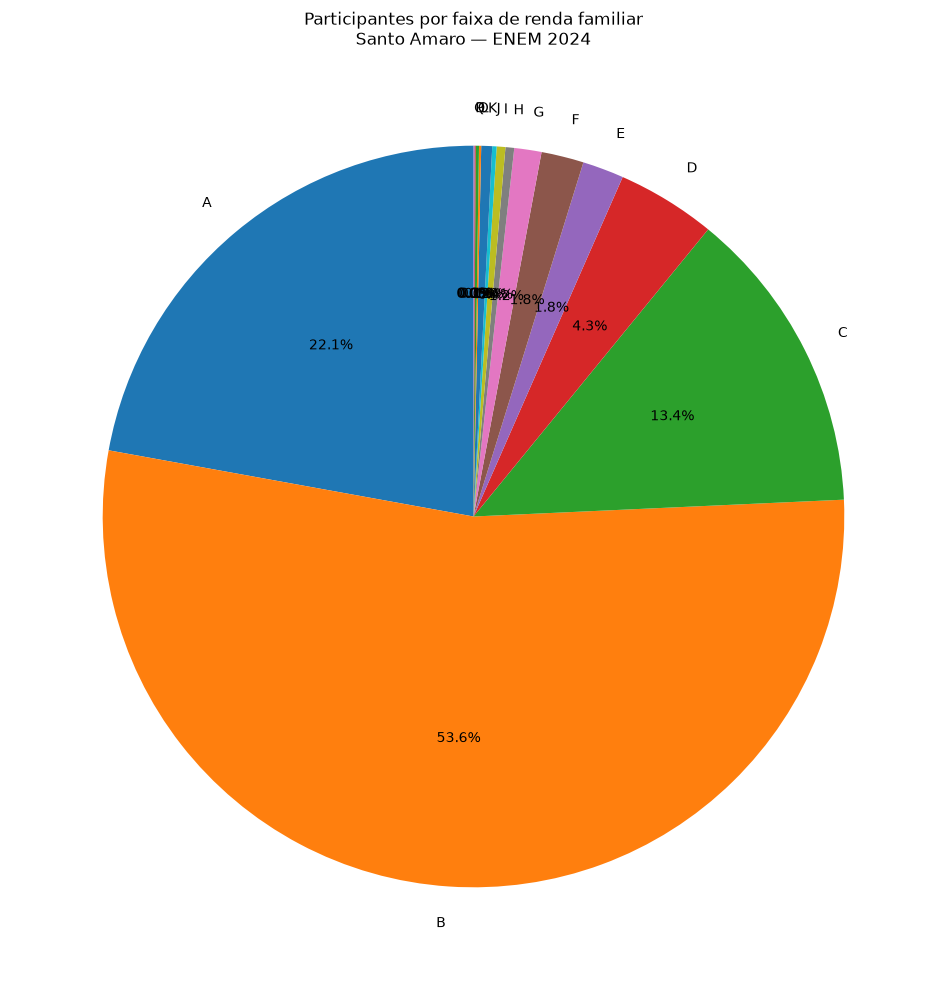

In [72]:
import matplotlib.pyplot as plt

renda_familiar = (
    df_santo_amaro['Q007']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 10))

plt.pie(
    renda_familiar,
    labels=renda_familiar.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title(
    'Participantes por faixa de renda familiar\n'
    'Santo Amaro — ENEM 2024'
)

plt.tight_layout()
plt.show()

In [73]:
# Agrupamento das categorias oficiais do Q007
grupos_renda = {
    'Sem renda': ['A'],
    'Até 1,5 SM': ['B', 'C'],
    'De 1,5 a 3 SM': ['D', 'E', 'F'],
    'De 3 a 6 SM': ['G', 'H', 'I'],
    'De 6 a 10 SM': ['J', 'K', 'L', 'M'],
    'Acima de 10 SM': ['N', 'O', 'P', 'Q']
}

# Cria um dicionário categoria Q007 -> grupo
mapa_renda = {
    categoria: grupo
    for grupo, categorias in grupos_renda.items()
    for categoria in categorias
}

# Cria a nova coluna
df_santo_amaro['GRUPO_RENDA'] = df_santo_amaro['Q007'].map(mapa_renda)

# Frequência dos grupos
distribuicao_renda = (
    df_santo_amaro['GRUPO_RENDA']
    .value_counts()
    .reindex(grupos_renda.keys())
)

distribuicao_renda

GRUPO_RENDA
Sem renda          467
Até 1,5 SM        1412
De 1,5 a 3 SM      168
De 3 a 6 SM         41
De 6 a 10 SM        16
Acima de 10 SM       5
Name: count, dtype: int64

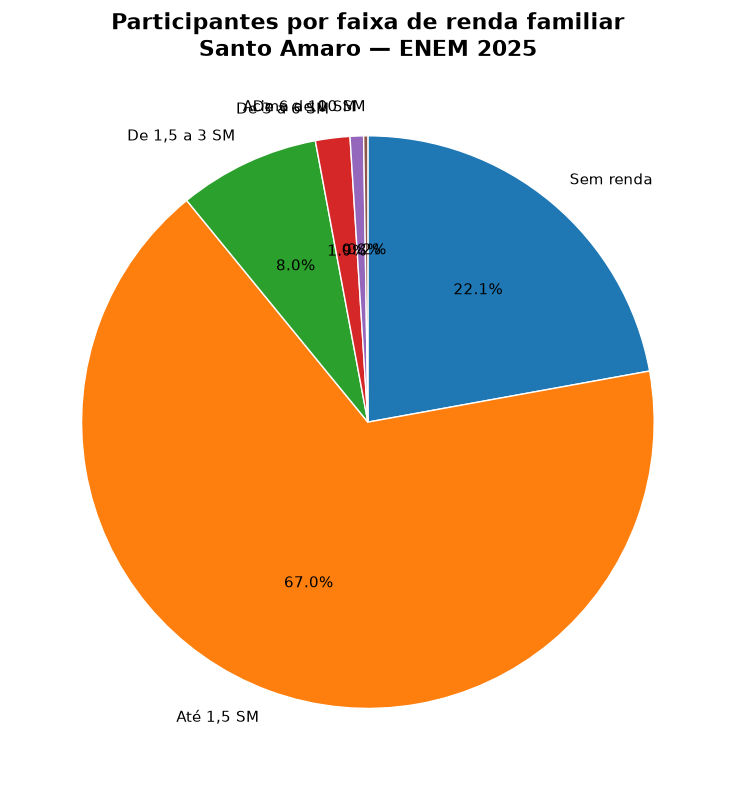

In [74]:
plt.figure(figsize=(10, 8))

plt.pie(
    distribuicao_renda,
    labels=distribuicao_renda.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    textprops={'fontsize': 11},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

plt.title(
    'Participantes por faixa de renda familiar\n'
    'Santo Amaro — ENEM 2025',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

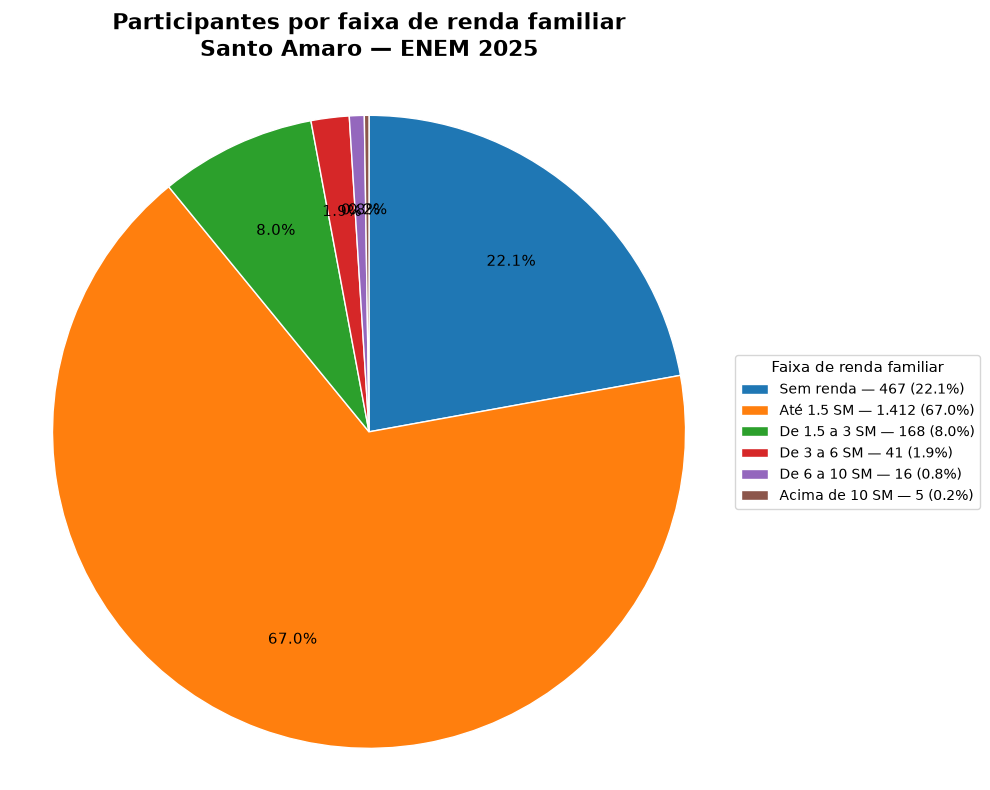

In [75]:
# Frequência dos grupos
distribuicao_renda = (
    df_santo_amaro['GRUPO_RENDA']
    .value_counts()
    .reindex(grupos_renda.keys())
)

total = distribuicao_renda.sum()

# Percentuais
percentuais = distribuicao_renda / total * 100

# Texto da legenda
legenda = [
    f'{grupo} — {valor:,} ({percentual:.1f}%)'.replace(',', '.')
    for grupo, valor, percentual
    in zip(
        distribuicao_renda.index,
        distribuicao_renda.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(10, 8))

ax.pie(
    distribuicao_renda,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 11},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Faixa de renda familiar',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=10,
    title_fontsize=11
)

ax.set_title(
    'Participantes por faixa de renda familiar\n'
    'Santo Amaro — ENEM 2025',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

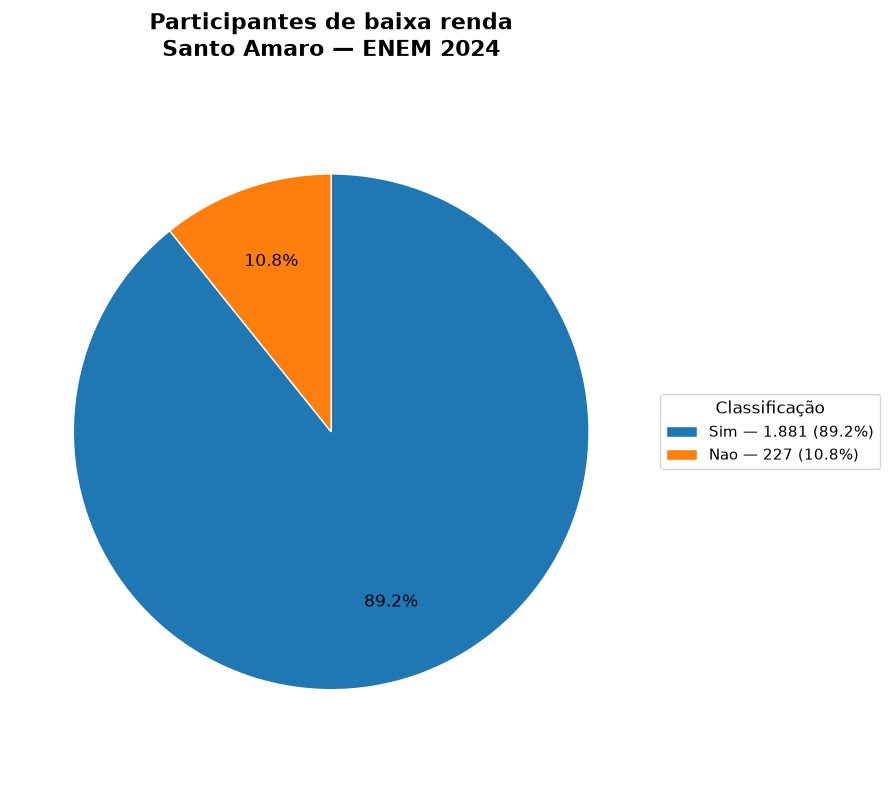

In [76]:
import matplotlib.pyplot as plt

distribuicao_baixa_renda = (
    df_santo_amaro['BAIXA_RENDA_EST']
    .dropna()
    .value_counts()
    .reindex(['Sim', 'Nao'], fill_value=0)
)

total = distribuicao_baixa_renda.sum()

percentuais = distribuicao_baixa_renda / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_baixa_renda.index,
        distribuicao_baixa_renda.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_baixa_renda,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Classificação',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Participantes de baixa renda\n'
    'Santo Amaro — ENEM 2024',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

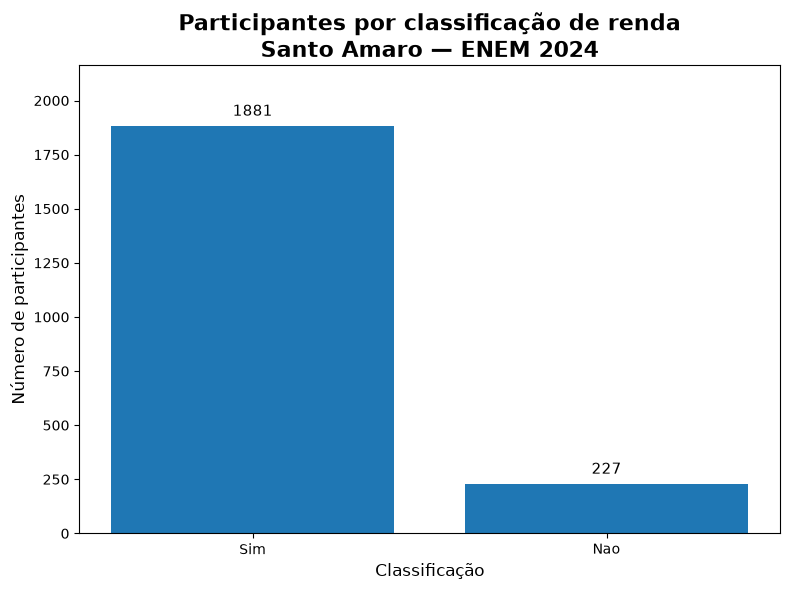

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(
    distribuicao_baixa_renda.index,
    distribuicao_baixa_renda.values
)

ax.set_title(
    'Participantes por classificação de renda\n'
    'Santo Amaro — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Classificação', fontsize=12)
ax.set_ylabel('Número de participantes', fontsize=12)

# Mostra o valor sobre cada barra
ax.bar_label(
    barras,
    fmt='%d',
    padding=5,
    fontsize=11
)

ax.set_ylim(
    0,
    distribuicao_baixa_renda.max() * 1.15
)

plt.tight_layout()
plt.show()

In [78]:
df_santo_amaro['TP_SEXO'].value_counts(dropna=False)

TP_SEXO
F    1420
M     689
Name: count, dtype: int64

In [79]:
distribuicao_sexo = (
    df_santo_amaro['TP_SEXO']
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)



In [80]:
nomes_sexo = {
    'M': 'Masculino',
    'F': 'Feminino'
}

distribuicao_sexo.index = distribuicao_sexo.index.map(nomes_sexo)

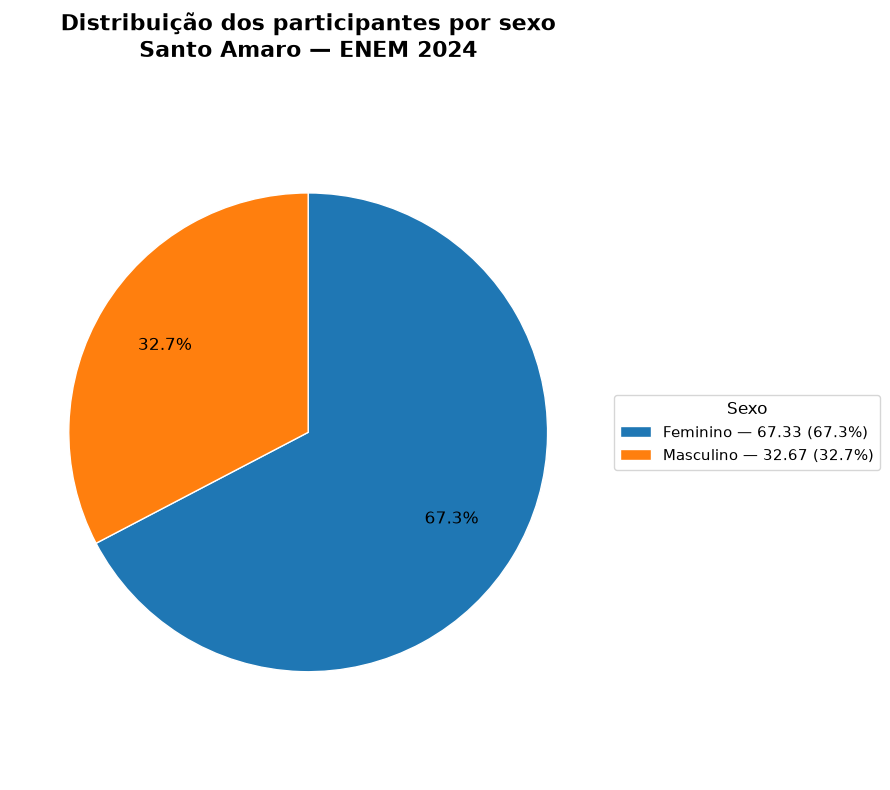

In [81]:
import matplotlib.pyplot as plt

total = distribuicao_sexo.sum()

percentuais = distribuicao_sexo / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_sexo.index,
        distribuicao_sexo.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_sexo,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Sexo',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Distribuição dos participantes por sexo\n'
    'Santo Amaro — ENEM 2024',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

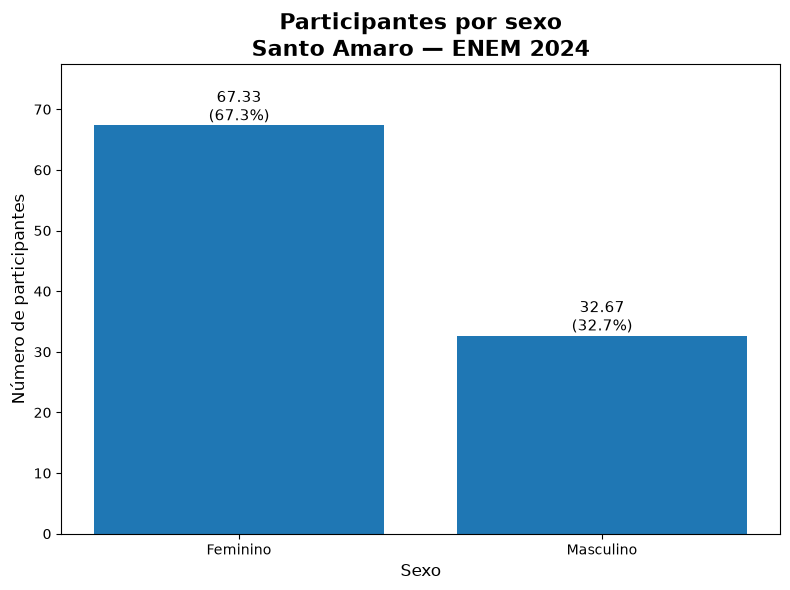

In [82]:
fig, ax = plt.subplots(figsize=(8, 6))

barras = ax.bar(
    distribuicao_sexo.index,
    distribuicao_sexo.values
)

for barra, valor in zip(barras, distribuicao_sexo.values):
    percentual = valor / total * 100
    
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f'{valor:,}\n({percentual:.1f}%)'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.set_title(
    'Participantes por sexo\n'
    'Santo Amaro — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Sexo', fontsize=12)
ax.set_ylabel('Número de participantes', fontsize=12)

ax.set_ylim(0, distribuicao_sexo.max() * 1.15)

plt.tight_layout()
plt.show()

In [83]:
df_santo_amaro['TP_COR_RACA'].value_counts(dropna=False)

TP_COR_RACA
2    1122
3     823
1     121
0      21
4      17
5       5
Name: count, dtype: int64

In [84]:
cor_raca = (
    df_santo_amaro['TP_COR_RACA']
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

cor_raca

TP_COR_RACA
2    53.20
3    39.02
1     5.74
0     1.00
4     0.81
5     0.24
Name: proportion, dtype: float64

In [85]:
mapa_cor_raca = {
    0: 'Não declarado',
    1: 'Branca',
    2: 'Preta',
    3: 'Parda',
    4: 'Amarela',
    5: 'Indígena'
}

df_santo_amaro['COR_RACA'] = (
    df_santo_amaro['TP_COR_RACA']
    .map(mapa_cor_raca)
)

In [86]:
df_santo_amaro['TP_COR_RACA'].value_counts(normalize=True).mul(100).sort_index()

TP_COR_RACA
0     0.995733
1     5.737316
2    53.200569
3    39.023234
4     0.806069
5     0.237079
Name: proportion, dtype: float64

In [87]:
df_santo_amaro['GRUPO_RACIAL'] = (
    df_santo_amaro['TP_COR_RACA']
    .map({
        0: 'Não declarado',
        1: 'Branca',
        2: 'Preta',
        3: 'Parda',
        4: 'Amarela',
        5: 'Indígena',
        6: 'Não dispõe da informação'
    })
)

In [88]:
df_santo_amaro['GRUPO_RACIAL'].value_counts()

GRUPO_RACIAL
Preta            1122
Parda             823
Branca            121
Não declarado      21
Amarela            17
Indígena            5
Name: count, dtype: int64

In [89]:
df_santo_amaro['NEGRO'] = (
    df_santo_amaro['TP_COR_RACA']
    .isin([2, 3])
    .map({
        True: 'Preta ou Parda',
        False: 'Demais categorias'
    })
)

In [90]:
distribuicao_negros = (
    df_santo_amaro['NEGRO']
    .value_counts()
)

distribuicao_negros

NEGRO
Preta ou Parda       1945
Demais categorias     164
Name: count, dtype: int64

In [91]:
percentuais_negros = (
    df_santo_amaro['NEGRO']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

percentuais_negros

NEGRO
Preta ou Parda       92.22
Demais categorias     7.78
Name: proportion, dtype: float64

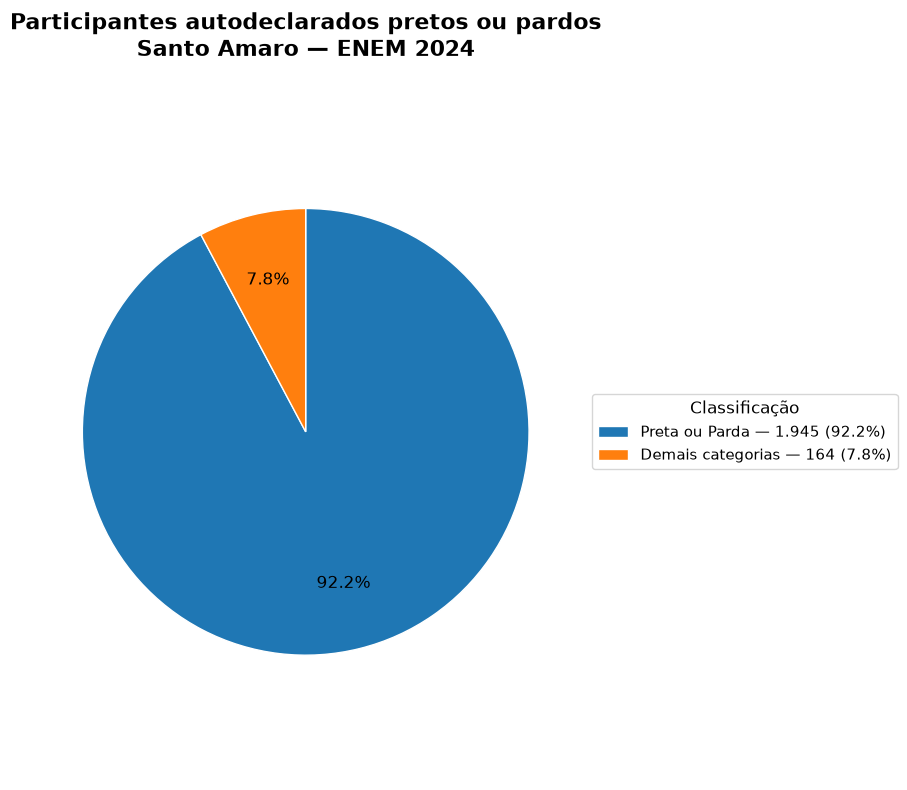

In [92]:
distribuicao_negros = (
    df_santo_amaro['NEGRO']
    .value_counts()
    .reindex(['Preta ou Parda', 'Demais categorias'])
)

total = distribuicao_negros.sum()

percentuais = distribuicao_negros / total * 100

legenda = [
    f'{categoria} — {quantidade:,} ({percentual:.1f}%)'.replace(',', '.')
    for categoria, quantidade, percentual
    in zip(
        distribuicao_negros.index,
        distribuicao_negros.values,
        percentuais.values
    )
]

fig, ax = plt.subplots(figsize=(9, 8))

ax.pie(
    distribuicao_negros,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.70,
    textprops={'fontsize': 12},
    wedgeprops={
        'linewidth': 1,
        'edgecolor': 'white'
    }
)

ax.legend(
    legenda,
    title='Classificação',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=11,
    title_fontsize=12
)

ax.set_title(
    'Participantes autodeclarados pretos ou pardos\n'
    'Santo Amaro — ENEM 2024',
    fontsize=16,
    fontweight='bold',
    pad=20
)

ax.axis('equal')

plt.tight_layout()
plt.show()

## Distribuição por Faixa Etária

In [93]:
df_santo_amaro['TP_FAIXA_ETARIA'].describe()

count    2109.000000
mean        6.110953
std         4.374436
min         1.000000
25%         3.000000
50%         4.000000
75%        10.000000
max        20.000000
Name: TP_FAIXA_ETARIA, dtype: float64

In [94]:
distribuicao_idade = (
    df_santo_amaro['TP_FAIXA_ETARIA']
    .value_counts()
    .sort_index()
)

distribuicao_idade

TP_FAIXA_ETARIA
1     131
2     323
3     419
4     242
5     133
6     105
7      70
8      72
9      58
10     48
11    158
12     96
13     88
14     79
15     43
16     20
17     18
18      3
19      2
20      1
Name: count, dtype: int64

In [95]:
percentuais_idade = (
    df_santo_amaro['TP_FAIXA_ETARIA']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

percentuais_idade

TP_FAIXA_ETARIA
1      6.21
2     15.32
3     19.87
4     11.47
5      6.31
6      4.98
7      3.32
8      3.41
9      2.75
10     2.28
11     7.49
12     4.55
13     4.17
14     3.75
15     2.04
16     0.95
17     0.85
18     0.14
19     0.09
20     0.05
Name: proportion, dtype: float64

In [96]:
faixas_etarias = {
    1: 'Menor de 17 anos',
    2: '17 anos',
    3: '18 anos',
    4: '19 anos',
    5: '20 anos',
    6: '21 anos',
    7: '22 anos',
    8: '23 anos',
    9: '24 anos',
    10: '25 anos',
    11: '26–30 anos',
    12: '31–35 anos',
    13: '36–40 anos',
    14: '41–45 anos',
    15: '46–50 anos',
    16: '51–55 anos',
    17: '56–60 anos',
    18: '61–65 anos',
    19: '66–70 anos',
    20: 'Maior de 70 anos'
}

df_santo_amaro['FAIXA_ETARIA'] = (
    df_santo_amaro['TP_FAIXA_ETARIA']
    .map(faixas_etarias)
)

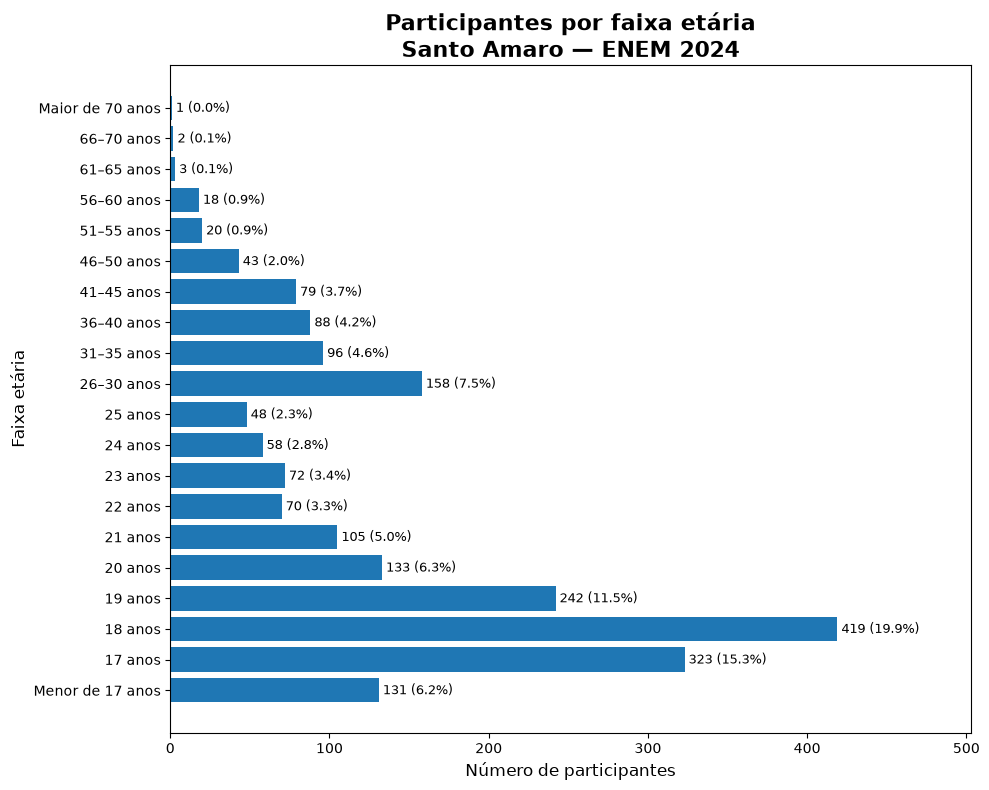

In [97]:
distribuicao_idade = (
    df_santo_amaro['FAIXA_ETARIA']
    .value_counts()
)

ordem_faixas = list(faixas_etarias.values())

distribuicao_idade = (
    distribuicao_idade
    .reindex(ordem_faixas)
    .dropna()
)

total = distribuicao_idade.sum()

percentuais = (
    distribuicao_idade / total * 100
)

fig, ax = plt.subplots(figsize=(10, 8))

barras = ax.barh(
    distribuicao_idade.index,
    distribuicao_idade.values
)

for barra, valor, percentual in zip(
    barras,
    distribuicao_idade.values,
    percentuais.values
):
    ax.text(
        barra.get_width(),
        barra.get_y() + barra.get_height() / 2,
        f' {int(valor):,} ({percentual:.1f}%)'.replace(',', '.'),
        va='center',
        fontsize=9
    )

ax.set_title(
    'Participantes por faixa etária\n'
    'Santo Amaro — ENEM 2024',
    fontsize=16,
    fontweight='bold'
)

ax.set_xlabel('Número de participantes', fontsize=12)
ax.set_ylabel('Faixa etária', fontsize=12)

ax.set_xlim(
    0,
    distribuicao_idade.max() * 1.20
)

plt.tight_layout()
plt.show()